In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [42]:
df=pd.read_csv('movies.csv')

C:\Users\Sulav\AppData\Local\Temp\ipykernel_20756\1554665796.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('movies.csv')


In [43]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [45]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [46]:
df.shape

(45466, 24)

In [47]:
df.isnull().sum()

adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

In [48]:
df = df.drop_duplicates().reset_index(drop=True)

In [49]:
df1=df['vote_average'].sort_values(ascending=False).value_counts()
df1.head()

vote_average
0.0    2997
6.0    2468
5.0    1999
7.0    1886
6.5    1722
Name: count, dtype: int64

<Axes: xlabel='vote_average', ylabel='Count'>

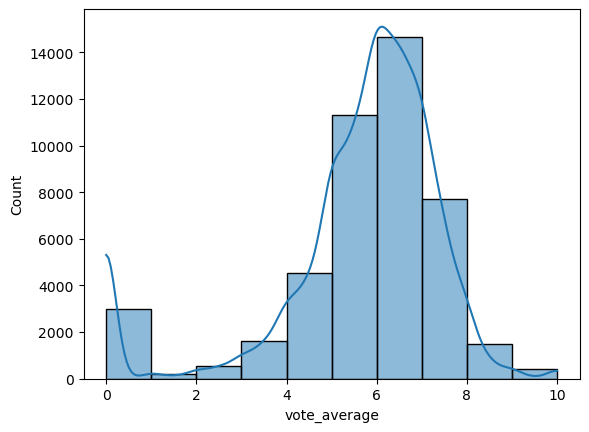

In [50]:
sns.histplot(x='vote_average', data=df, bins=10, kde=True)

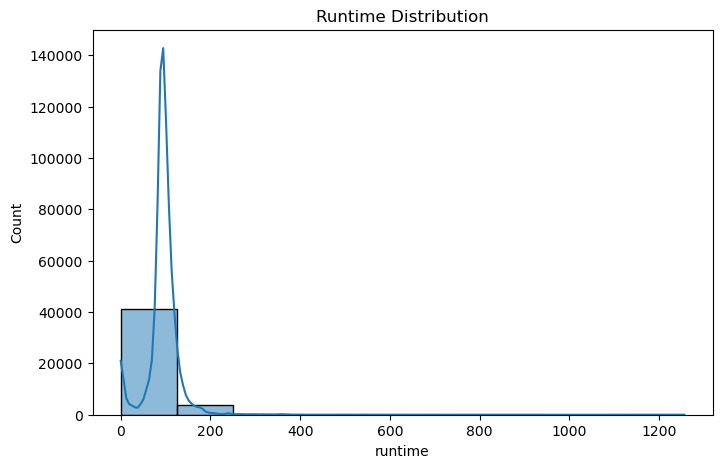

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df['runtime'], bins=10, kde=True)

plt.title("Runtime Distribution")

plt.show()

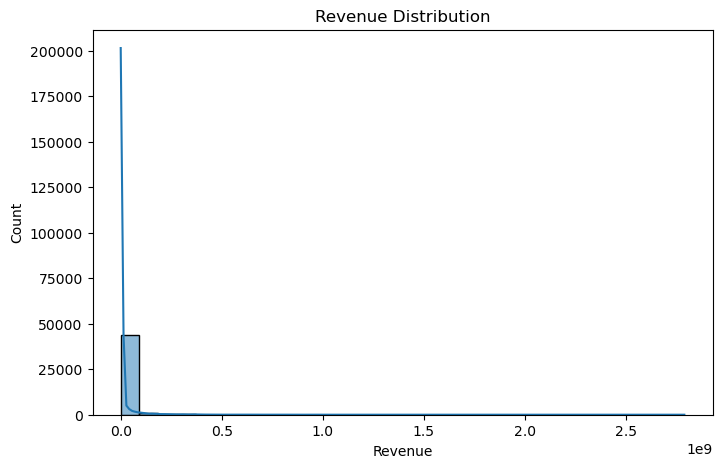

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df['revenue'], bins=30, kde=True)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

In [53]:
#top 10 language
top=df['original_language'].value_counts()
top

original_language
en       32262
fr        2437
it        1529
ja        1350
de        1079
         ...  
zu           1
qu           1
104.0        1
la           1
si           1
Name: count, Length: 92, dtype: int64

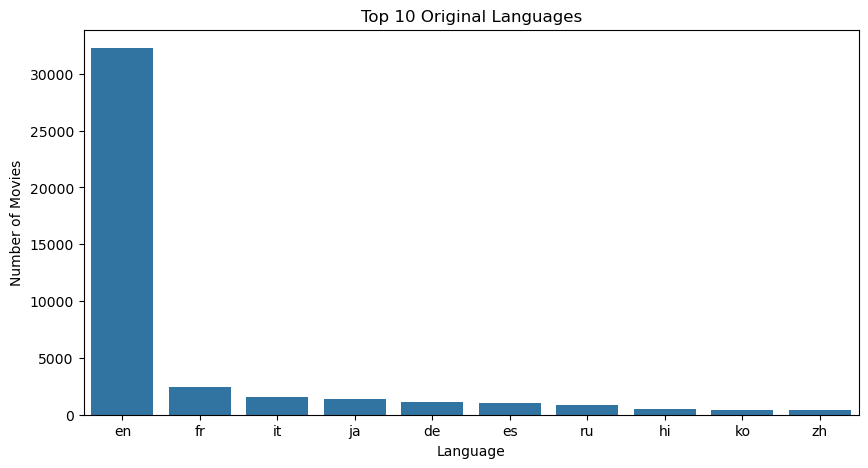

In [54]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='original_language',
    order=df['original_language'].value_counts().head(10).index
)

plt.title("Top 10 Original Languages")
plt.xlabel("Language")
plt.ylabel("Number of Movies")
plt.show()

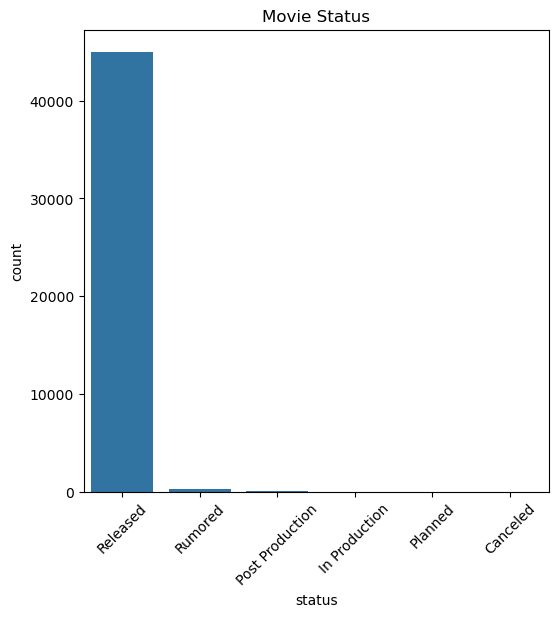

In [55]:
#movie status
plt.figure(figsize=(6,6))
sns.countplot(x='status',data=df)
plt.title("Movie Status")
plt.xticks(rotation=45)
plt.show()

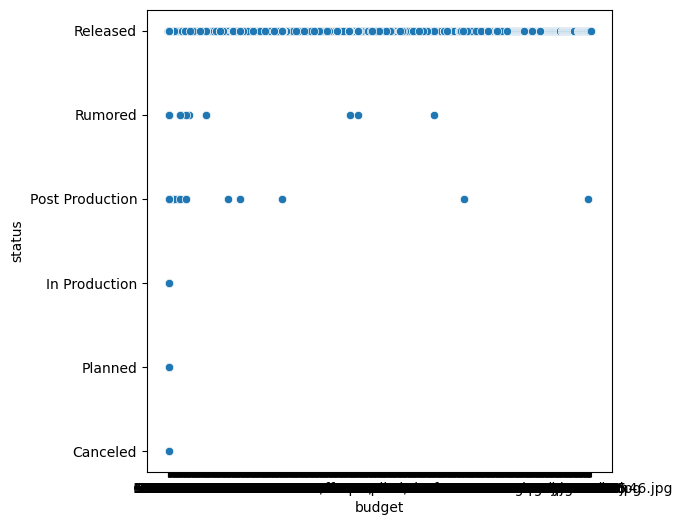

In [56]:
#budget vs status
plt.figure(figsize=(6,6))
sns.scatterplot(x='budget',y='status',data=df)
plt.show()

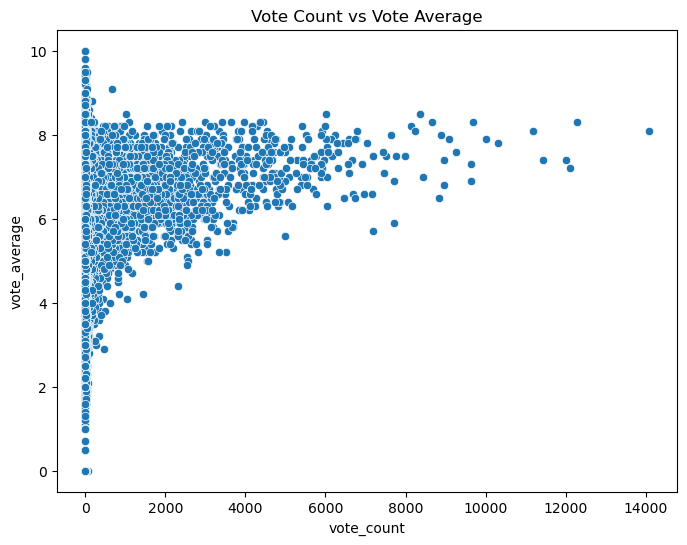

In [57]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='vote_count',
    y='vote_average'
)

plt.title("Vote Count vs Vote Average")
plt.show()

In [58]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [59]:
print(df[['revenue','runtime','vote_average','vote_count']].dtypes)

revenue         float64
runtime         float64
vote_average    float64
vote_count      float64
dtype: object


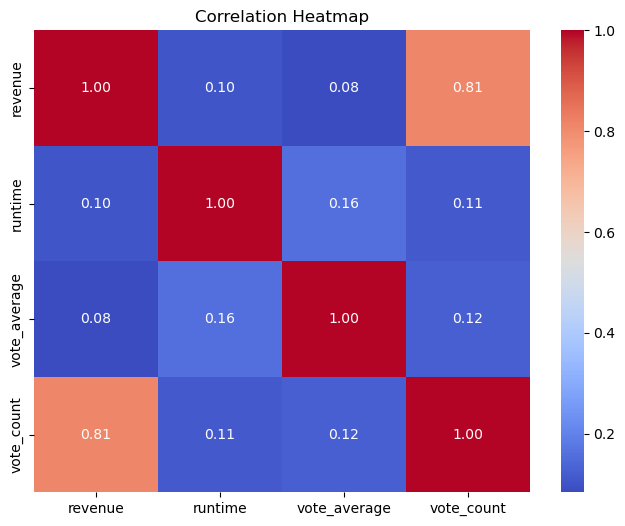

In [60]:
plt.figure(figsize=(8,6))

corr = df[['revenue','runtime','vote_average','vote_count']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

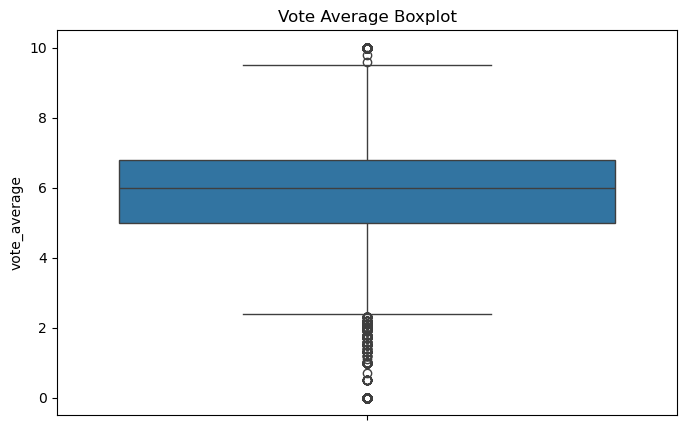

In [61]:
#rating boxplot
plt.figure(figsize=(8,5))

sns.boxplot(df['vote_average'])

plt.title("Vote Average Boxplot")
plt.show()

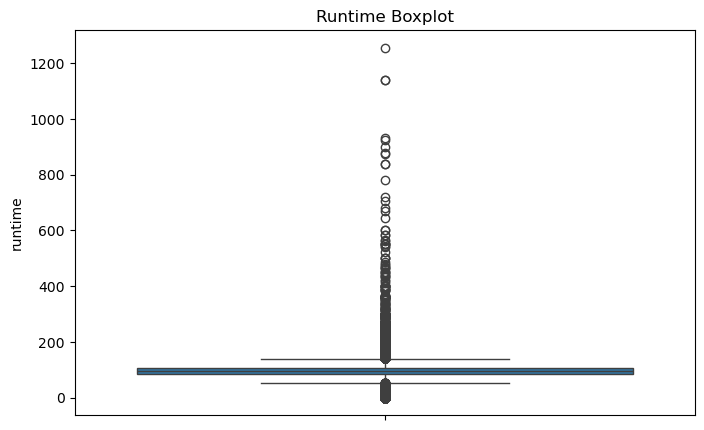

In [62]:
#runtime boxplot
plt.figure(figsize=(8,5))
sns.boxplot(df['runtime'])
plt.title("Runtime Boxplot")
plt.show()

In [63]:
top2=df['vote_average'].sort_values(ascending=False)


In [ ]:
plt.figure(figsize=(6,6))
plt.bar(top2.index,top2.values)
plt.show()

In [ ]:
sns.pairplot(
    df[['budget','revenue','runtime','vote_average','vote_count']].dropna()
)

plt.show()

In [ ]:
#hamilai model banauda use huney column haru matra use gareko
df = df[['title', 'overview', 'genres', 'tagline', 'vote_average', 'popularity']]

In [ ]:
df

In [ ]:
df.isnull().sum()

In [ ]:
#title ma bhayeko sabai null  value lai drop gareko
df=df.dropna(subset=['title'])

In [ ]:
#filling empty value or space in overview
df['overview']=df['overview'].fillna('')

In [ ]:
df.iloc[0]['genres']

In [ ]:
import ast

# Yo code le genres column ma bhayeko string lai Python list ma convert garcha,
# harek movie ko genre ko name matra nikalcha,
# ani sabai genre lai space le join garera simple text format ma convert garcha.

df['genres'] = df['genres'].apply(
    lambda x: " ".join([i['name'] for i in ast.literal_eval(x)])
)

In [ ]:
df.head()

In [ ]:
#fiilling tagline
df['tagline']=df['tagline'].fillna('')

In [ ]:
df.isnull().sum()

# now all null or error value are cleaned 

In [ ]:
df['tags']=df['overview']+ " "+df['genres']+ " "+df['tagline']

In [ ]:
df.head()

# USING NLP(Natural Language Processing)
# Natural Language Processing (NLP) is a field of Artificial Intelligence (AI) that enables computers to understand, interpret, and generate human language.



# Removing stop words like is,the,a,an

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

In [ ]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required resources
nltk.download('stopwords')
nltk.download('wordnet')

# Create stopwords set
stop_words = set(stopwords.words('english'))

# Create lemmatizer
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenize
    words = text.split()
    
    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    # Lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]
    
    # Join words back into text
    return ' '.join(words)

In [ ]:
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

In [ ]:
df['tags']=df['tags'].apply(preprocess_text)

In [ ]:
df.head()

In [ ]:
df['tags'][1]
# here nlp is used so all punctuation is removed,tokenize,remove stop words 